# 17.1.2 锁定 Neural ODE 任务与改编边界

## 学习目标与先修知识

区分连续伴随方法、原论文潜变量螺旋实验和本课程二维缩减实验。

先修：15.3 连续伴随与观测（observation）跳跃；17.1.1 研究主张。

## 具体问题

原论文用神经常微分方程（neural ordinary differential equation，Neural ODE）学习低维螺旋。要比较学习结果，先确定观测时刻、损失和外推条件，再用解析螺旋建立计算参照。

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
times=np.linspace(0,3,61);print("初值与末值：",[1.,0.],[np.exp(-.08*3)*np.cos(2*3),np.exp(-.08*3)*np.sin(2*3)])

初值与末值： [1.0, 0.0] [np.float64(0.7552966988474369), np.float64(-0.21979601569706647)]


## 模型假设

R19 固定 arXiv:1806.07366v1。原文低维任务含大量带噪二维轨迹（trajectory）、稀疏观测、RNN 编码器、四维潜变量与独立外推测试。本课程保留二维螺旋几何、连续时间动力学及伴随跳跃，但用四参数（parameter）可见向量场（vector field）和较少轨迹；状态（state）无量纲（dimensionless）、时间以 T 计，a、ω、c、d 的单位为 1/T。课程实验以可见状态的四参数场替代潜变量架构，重点是连续伴随的计算与核对。

## 数学解释与推导

方法核心为 $\dot z=f(z,t,\theta)$。对离散观测损失 $L=\frac1{2m}\sum_j\|z(t_j)-y_j\|^2$，连续伴随满足 $\dot\lambda=-(\partial_z f)^\mathsf T\lambda$，观测时刻反向越过时加入 $(z(t_j)-y_j)/m$。参数梯度（gradient）由 $-\lambda^\mathsf T\partial_\theta f$ 反向积分。本节先建立独立解析螺旋基准，下一章实现伴随；数值轨迹采用固定步长 RK4。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def spiral_exact(initial,a,omega,times):
    initial=np.asarray(initial,dtype=float);times=np.asarray(times,dtype=float)
    theta=omega*times;factor=np.exp(-a*times)
    return np.column_stack([factor*(initial[0]*np.cos(theta)-initial[1]*np.sin(theta)),
                            factor*(initial[0]*np.sin(theta)+initial[1]*np.cos(theta))])


def spiral_rhs(state, parameters):
    """Four-parameter tanh vector field; linear damped spiral when c=d=0."""
    x,y=np.asarray(state,dtype=float);a,omega,c,d=parameters
    return np.array([-a*x-omega*y+c*np.tanh(x),omega*x-a*y+d*np.tanh(y)])


def spiral_state_jacobian(state, parameters):
    x,y=np.asarray(state,dtype=float);a,omega,c,d=parameters
    return np.array([[-a+c*(1-np.tanh(x)**2),-omega],
                     [omega,-a+d*(1-np.tanh(y)**2)]])


def spiral_parameter_jacobian(state, parameters):
    x,y=np.asarray(state,dtype=float)
    return np.array([[-x,-y,np.tanh(x),0.],[-y,x,0.,np.tanh(y)]])


def rk4_path(rhs, initial, h, steps):
    state=np.asarray(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        k1=np.asarray(rhs(state));k2=np.asarray(rhs(state+h*k1/2))
        k3=np.asarray(rhs(state+h*k2/2));k4=np.asarray(rhs(state+h*k3))
        state=state+h*(k1+2*k2+2*k3+k4)/6
        rows.append(state.copy())
    return np.asarray(rows)


def rk4_spiral(initial,parameters,h,steps):
    return rk4_path(lambda state:spiral_rhs(state,parameters),initial,h,steps)

## 对照实验

将相同时刻的 RK4 轨迹与解析螺旋叠加，检查数值积分是否保持了衰减与旋转。

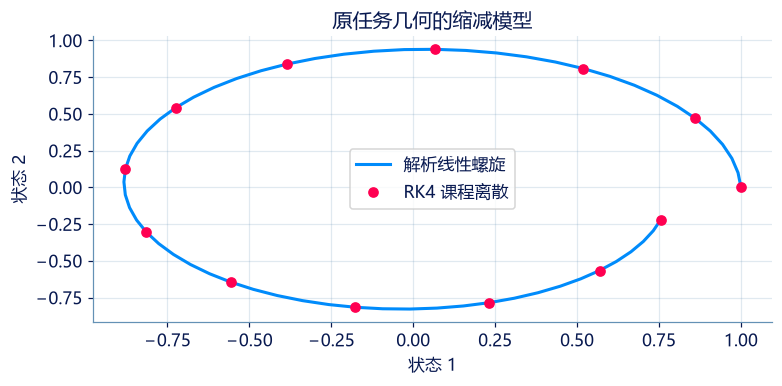

In [4]:
times=np.arange(61)*.05;exact=spiral_exact([1.,0.],.08,2.,times);numeric=rk4_spiral([1.,0.],[.08,2.,0.,0.],.05,60)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(exact[:,0],exact[:,1],label="解析线性螺旋",color=BLUE);ax.plot(numeric[::5,0],numeric[::5,1],"o",label="RK4 课程离散",color=PINK);ax.set(xlabel="状态 1",ylabel="状态 2",title="原任务几何的缩减模型");ax.legend();ax.grid(alpha=.2);plt.show()

## 结果解释

将数值轨迹与解析螺旋比较，可以检查积分误差；后续训练再用这组状态和观测时刻构造损失。

### 独立核对

将数值轨迹逐点与解析解（analytical solution）比较，再代入初态核对向量场。

In [5]:
np.testing.assert_allclose(numeric,exact,atol=3e-5);np.testing.assert_allclose(spiral_rhs([1.,0.],[.08,2.,0.,0.]),[-.08,2.])
print("独立解析解与向量场代入通过。")

独立解析解与向量场代入通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：相似曲线与论文结果

课程二维螺旋与原论文实验最准确的关系是什么？

- **A.** 已经复现全部潜变量训练
- **B.** 已经复现论文 Table 2
- **C.** 只覆盖几何和核心方法的缩减任务
- **D.** 已证明对真实临床轨迹（trajectory）有效

[作答：相似曲线与论文结果](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-c1s2-choice1)

### 第 2 题 · 单项选择题：观测跳跃

连续伴随反向越过观测（observation）时刻，应怎样处理？

- **A.** 清空伴随变量
- **B.** 把该点的损失状态（state）梯度（gradient）加到伴随变量
- **C.** 读取未来测试标签调参
- **D.** 忽略该点损失

[作答：观测跳跃](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-c1s2-choice2)

### 第 3 题 · Python 计算题：缩减神经向量场

原论文用神经常微分方程（neural ordinary differential equation，Neural ODE）学习低维螺旋。只画一条类似螺旋，能否称为原结果复现？本题计算“缩减神经向量场（vector field）”：f=[-a*x-omega*y+c*tanh(x),omega*x-a*y+d*tanh(y)]。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    state: list[float],
    parameters: list[float],
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 二维当前状态（state）。 | 1 |
| `parameters` | `list[float]` | 按 a、omega、c、d 顺序的向量场参数。 | 1/T |

**返回值**

直接返回 rates（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 二维状态变化率。 | 1/T |

**计算规则**

f=[-a*x-omega*y+c*tanh(x),omega*x-a*y+d*tanh(y)]。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 二维当前状态（state）。 | [1.0, 0.0] | 1 |
| parameters | 按 a、omega、c、d 顺序的向量场参数。 | [0.1, 2.0, 0.0, 0.0] | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1.0, 0.0]
parameters = [0.1, 2.0, 0.0, 0.0]

result = solve(state, parameters)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | 二维状态变化率。 | [-0.1, 2.0] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [-0.1, 2.0]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；f=[-a*x-omega*y+c*tanh(x),omega*x-a*y+d*tanh(y)]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：缩减神经向量场](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-spiral-vector)

### 第 4 题 · Python 计算题：解析螺旋参考

原论文用神经常微分方程（neural ordinary differential equation，Neural ODE）学习低维螺旋。只画一条类似螺旋，能否称为原结果复现？本题计算“解析螺旋参考”：每个时刻用 exp(-a*t) 乘旋转矩阵（matrix）作用于 initial。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    initial: list[float],
    a: float,
    omega: float,
    times: list[float],
) -> list[list[float]]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[float]` | 二维线性螺旋初态。 | 归一化状态 |
| `a` | `float` | 指数衰减率。 | 1/T |
| `omega` | `float` | 旋转角频率。 | 1/T |
| `times` | `list[float]` | 从初态开始的时间。 | T |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 每个时间对应的二维解析状态（state）。 | 归一化状态 |

**计算规则**

每个时刻用 exp(-a*t) 乘旋转矩阵作用于 initial。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 二维线性螺旋初态。 | [1.0, 0.0] | 归一化状态 |
| a | 指数衰减率。 | 0 | 1/T |
| omega | 旋转角频率。 | 0 | 1/T |
| times | 从初态开始的时间。 | [0.0, 1.0] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [1.0, 0.0]
a = 0.0
omega = 0.0
times = [0.0, 1.0]

result = solve(initial, a, omega, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 每个时间对应的二维解析状态（state）。 | [[1.0, 0.0], [1.0, 0.0]] | 归一化状态 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1.0, 0.0], [1.0, 0.0]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；每个时刻用 exp(-a*t) 乘旋转矩阵作用于 initial。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：解析螺旋参考](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-spiral-reference)

**原始参考**

[Chen 等，arXiv:1806.07366v1](https://arxiv.org/abs/1806.07366v1)